In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [3]:
# 1. UCI'dan veri setini doğrudan çekme
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
    'ca', 'thal', 'target'
]

# Veri setini yükleme (? işaretleri eksik veri olarak işaretlenir)
df = pd.read_csv(url, names=columns, na_values='?')

# Eksik verileri doldurma / temizleme (az sayıda eksik satır var)
df = df.dropna()

# Hedef değişken: 0 (sağlıklı), 1-4 (kalp hastalığı var). İkili sınıflandırmaya çeviriyoruz (0 ve 1)
df['target'] = (df['target'] > 0).astype(int)

# 2. X ve y ayrımı
X = df.drop('target', axis=1)
y = df['target']

# Train-Test bölme (%80 Eğitim, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
# ---------------------------------------------------------
# MODEL 1: Decision Tree (Karar Ağacı)
# ---------------------------------------------------------
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, y_pred_dt)

In [5]:
# ---------------------------------------------------------
# MODEL 2: Random Forest (Rastgele Orman)
# ---------------------------------------------------------
rf_model = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

# Sonuçları yazdırma
print(f"--- SONUÇLAR ---")
print(f"Decision Tree Doğruluk Skoru : {dt_acc:.4f}")
print(f"Random Forest Doğruluk Skoru : {rf_acc:.4f}\n")
print("Random Forest Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred_rf))

--- SONUÇLAR ---
Decision Tree Doğruluk Skoru : 0.8000
Random Forest Doğruluk Skoru : 0.8500

Random Forest Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.81      0.94      0.87        32
           1       0.91      0.75      0.82        28

    accuracy                           0.85        60
   macro avg       0.86      0.84      0.85        60
weighted avg       0.86      0.85      0.85        60



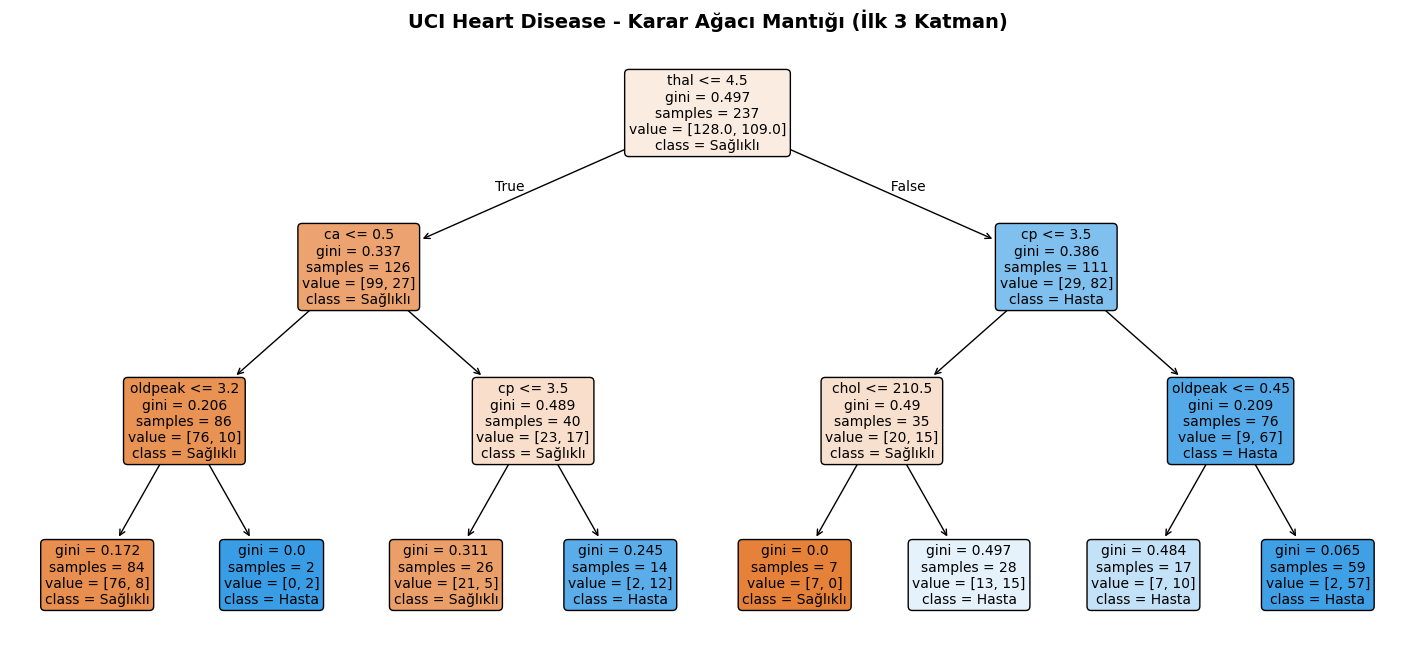

In [6]:
# ---------------------------------------------------------
# GÖRSELLEŞTİRME: Karar Ağacını Çizdirme
# ---------------------------------------------------------
plt.figure(figsize=(18, 8))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['Sağlıklı', 'Hasta'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("UCI Heart Disease - Karar Ağacı Mantığı (İlk 3 Katman)", fontsize=14, fontweight='bold')
plt.show()